## Comparing populations: Pakistan, Indians in UK, Chinese, Finland, African in USA. 


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os.path import join
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mylib import genomes

In [3]:
root_dir = join(Path.home(),"projects/cp_als/populations")

In [4]:
def one_population(population_name:str,genomes):
    infile = join(root_dir,f"output/{population_name}/all.csv")
    df = pd.read_csv(infile)
    df = df[genomes[population_name] + ["gene"]]
    sdf = df.groupby(["gene"]).sum()
    tdf = sdf.transpose()
    return tdf

In [5]:
khv= one_population(population_name="KHV",genomes=genomes)
chb= one_population(population_name="CHB",genomes=genomes)
gbr= one_population(population_name="GBR",genomes=genomes)
fin= one_population(population_name="FIN",genomes=genomes)
asw= one_population(population_name="ASW",genomes=genomes)
jpt= one_population(population_name="JPT",genomes=genomes)
clm = one_population(population_name="CLM",genomes=genomes)
chs = one_population(population_name="CHS",genomes=genomes)
cdx = one_population(population_name="CDX",genomes=genomes)
gih = one_population(population_name="GIH",genomes=genomes)
itu = one_population(population_name="ITU",genomes=genomes)
stu = one_population(population_name="STU",genomes=genomes)
mxl = one_population(population_name="MXL",genomes=genomes)
pur = one_population(population_name="PUR",genomes=genomes)
pjl = one_population(population_name="PJL",genomes=genomes)
beb = one_population(population_name="BEB",genomes=genomes)
acb = one_population(population_name="ACB",genomes=genomes)
esn = one_population(population_name="ESN",genomes=genomes)
gwd = one_population(population_name="GWD",genomes=genomes)
lwk = one_population(population_name="LWK",genomes=genomes)
msl = one_population(population_name="MSL",genomes=genomes)
yri = one_population(population_name="YRI",genomes=genomes)

# Remove ALS-associated genes before PCA
_genes_to_remove = ["FUS", "SOD1", "TARDBP", "CHMP2B"]
# khv, chb, gbr, fin, asw, jpt, clm, chs, cdx, gih, itu, stu, mxl, pur, pjl, beb, acb, esn, gwd, lwk, msl, yri = [
#     p.drop(columns=_genes_to_remove, errors="ignore")
#     for p in [khv, chb, gbr, fin, asw, jpt, clm, chs, cdx, gih, itu, stu, mxl, pur, pjl, beb, acb, esn, gwd, lwk, msl, yri]
# ]

In [6]:
df=pd.concat([esn,pjl,chs,fin,itu])
df = df.drop(columns=_genes_to_remove, errors="ignore")

In [7]:
df

gene,ALS2,ANG,ATXN2,C19ORF12,C9ORF72,CHCHD10,CHRNA3,CREST,DAO,DCTN1,...,SETX,SIGMAR1,SPG11,SQSTM1,TAF15,TUBA4A,VAPB,VCP,hnRNPA2B1,hnRNPa1
HG03136,147,18,83,29,56,9,52,97,5,8,...,228,1,24,70,48,3,44,10,10,3
HG03193,113,12,162,24,52,7,35,145,43,51,...,229,1,65,69,34,0,105,8,6,3
HG03343,132,18,225,29,9,7,47,41,35,41,...,160,2,59,46,8,3,90,14,6,3
HG02973,132,24,217,24,43,9,54,100,45,25,...,153,1,82,70,37,7,88,6,8,2
HG03105,112,17,206,38,48,8,32,108,24,27,...,150,1,118,64,32,6,105,21,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HG04202,104,17,93,19,49,4,49,116,3,4,...,99,2,20,49,2,4,26,19,1,3
HG04026,105,26,90,16,36,7,25,117,2,3,...,230,3,16,51,56,6,74,9,2,2
HG04222,92,17,36,13,47,7,53,114,5,2,...,223,1,12,57,5,7,5,17,3,3
HG03978,126,25,31,15,55,7,56,115,43,1,...,226,1,13,50,55,4,5,18,3,3


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [10]:
df['PC1'] = X_pca[:,0]
df['PC2'] = X_pca[:,1]

In [11]:
target_population = "india"

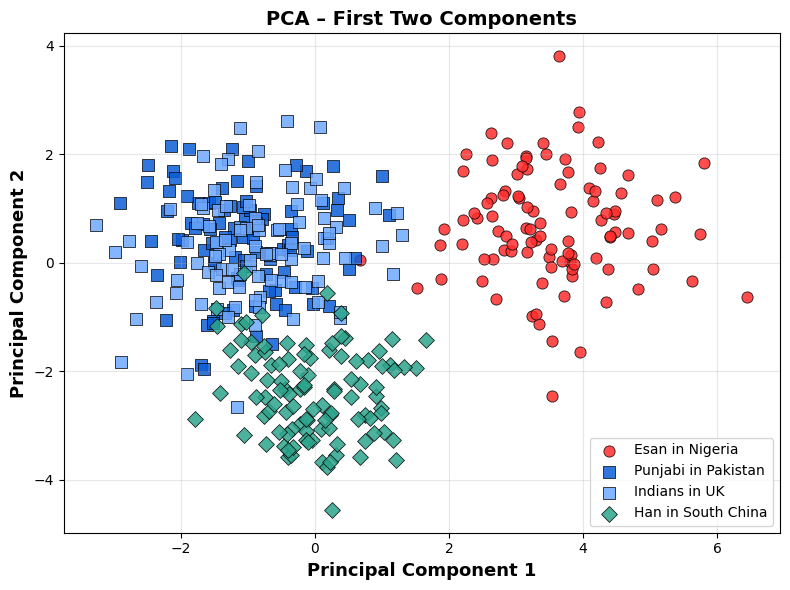

In [12]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(8,6))

# Improved distance-aware palette
colors = {
    "ESN": "#FF2D2D",  # bright red (very distinct)
    "PJL": "#0B5ED7",  # strong dark blue
    "ITU": "#6FA8FF",  # lighter blue (similar but distinguishable)
    "CHS": "#2CA58D"   # teal (moderately close)
}

# ESN — farthest → bright color + circle
plt.scatter(
    df.loc[genomes["ESN"]]['PC1'],
    df.loc[genomes["ESN"]]['PC2'],
    c=colors["ESN"], alpha=0.85,
    edgecolor='black', linewidth=0.6,
    s=65, label='Esan in Nigeria', marker='o'
)

# PJL — similar group
plt.scatter(
    df.loc[genomes["PJL"]]['PC1'],
    df.loc[genomes["PJL"]]['PC2'],
    c=colors["PJL"], alpha=0.85,
    edgecolor='black', linewidth=0.6,
    s=65, label='Punjabi in Pakistan', marker='s'
)

# ITU — same shape but clearly distinguishable color
plt.scatter(
    df.loc[genomes["ITU"]]['PC1'],
    df.loc[genomes["ITU"]]['PC2'],
    c=colors["ITU"], alpha=0.85,
    edgecolor='black', linewidth=0.6,
    s=65, label='Indians in UK', marker='s'
)

# CHS — moderate difference
plt.scatter(
    df.loc[genomes["CHS"]]['PC1'],
    df.loc[genomes["CHS"]]['PC2'],
    c=colors["CHS"], alpha=0.85,
    edgecolor='black', linewidth=0.6,
    s=65, label='Han in South China', marker='D'
)

plt.xlabel('Principal Component 1', fontsize=13, fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=13, fontweight='bold')
plt.title('PCA – First Two Components', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# os.makedirs('plots', exist_ok=True)
# output_file = f'plots/{target_population}_pca_first_two_components.png'
# plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()
